<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula03b_regress%C3%A3o_linear%20equa%C3%A7%C3%A3o%20normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

X = housing.data
y = housing.target

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


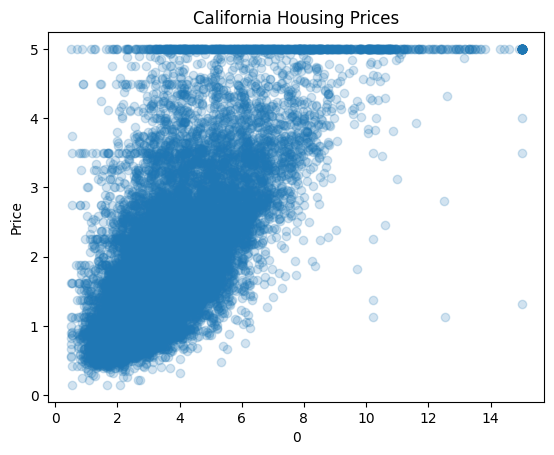

In [69]:
from matplotlib import pyplot as plt

def plot_regression_dataset(X, y, feat_idx=0):
  plt.scatter(X[:, feat_idx],
              y, alpha=0.2)
  plt.xlabel(feat_idx)
  plt.ylabel("Price")
  plt.title("California Housing Prices")

plot_regression_dataset(X_train, y_train, 0)
plt.show()

In [70]:
from matplotlib import pyplot as plt

def plot_predictions(y, y_pred, feat_idx=0):
  plt.scatter(X_train[:, feat_idx],
              y_train, alpha=0.2)
  plt.scatter(X_train[:, feat_idx],
              y_pred, alpha=0.2)
  plt.xlabel(f"Feature {feat_idx}")
  plt.ylabel("Price")
  plt.legend(["Actual", "Predicted"])
  plt.title("California Housing Prices")



In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Regressão Linear Simples

$\hat y = \beta_0 + \beta_1x$



$\beta_0$: intercepto;
$\beta_1$: coeficiênte

0.7196757085831575


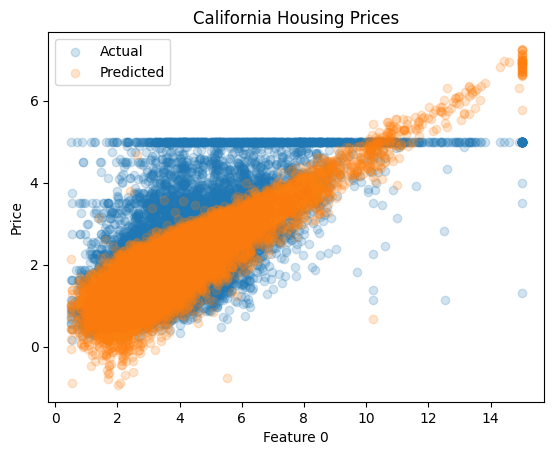

In [77]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import root_mean_squared_error

def include_bias(X):
  return np.c_[np.ones(shape=(X.shape[0], 1)), X]

class LinearRegression(BaseEstimator, RegressorMixin):
  def __init__(self, max_iter=200_000, learning_rate=0.00001):
    self.max_iter = max_iter
    self.learning_rate = learning_rate

  def fit(self, X, y):
    Xb = include_bias(X)
    self.coefs_ = np.zeros(shape=(Xb.shape[1],))
    for i in range(self.max_iter):
      y_pred = Xb @ self.coefs_
      error = y - y_pred
      self.coefs_ += Xb.T @ error * self.learning_rate
    return self

  def predict(self, X):
    Xb = include_bias(X)
    return Xb @ self.coefs_

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_train_scaled)
print(root_mean_squared_error(y_train, y_pred))
plot_predictions(y_train, y_pred)
plt.show()

0.7196757085831575


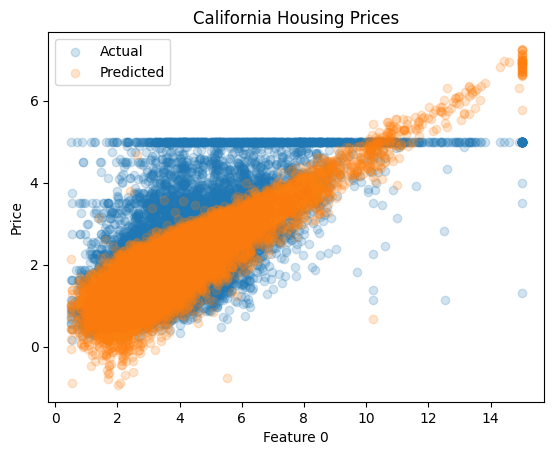

In [78]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import root_mean_squared_error

def include_bias(X):
  return np.c_[np.ones(shape=(X.shape[0], 1)), X]

class PseudoInverseLinearRegression(BaseEstimator, RegressorMixin):
  def fit(self, X, y):
    Xb = include_bias(X)
    self.coefs_ = np.linalg.pinv(Xb) @ y
    return self

  def predict(self, X):
    Xb = include_bias(X)
    return Xb @ self.coefs_

model = PseudoInverseLinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_train_scaled)
print(root_mean_squared_error(y_train, y_pred))
plot_predictions(y_train, y_pred)
plt.show()